<div style="
    background-color: #7BAFD4;
    border-radius: 18px;
    padding: 22px 26px;
    display: flex;
    align-items: center;
    gap: 24px;
    margin-bottom: 18px;
">
    <div>
        <div style="
            font-family: Impact, 'Arial Black', Arial, sans-serif;
            font-size: 42px;
            font-weight: 900;
            letter-spacing: 2px;
            line-height: 1;
            color: white;
        ">GEOG 592</div>
        <div style="
            font-family: Arial, Helvetica, sans-serif;
            font-size: 22px;
            font-weight: 700;
            color: #13294B;
            margin-top: 8px;
        ">GIS Programming</div>
        <div style="
            font-family: Arial, Helvetica, sans-serif;
            font-size: 16px;
            color: #13294B;
            margin-top: 6px;
        ">Module 4 — NumPy for Spatial Computing</div>
    </div>
</div>

# NumPy for Spatial Computing

NumPy is one of the foundational libraries of scientific Python. It is especially important in GIS because spatial data often contains **large collections of numeric values.**
Today we will focus on the NumPy ideas that are most useful for understanding later GIS programming.

### By the end of class, you should be able to:

- create a NumPy array, and compare to Python lists
- inspect array shapes
- select rows and columns from a 2D array
- perform arithmetic with entire arrays
- create Boolean masks
- use `np.where()` for conditional classification
- calculate distances and code spatial queries from coordinate arrays
- explain what **vectorization** means

## Why NumPy matters

A large part of GIS is numerical computation.

Examples include:

- storing thousands or millions of coordinates;
- calculating distances;
- transforming coordinates;
- working with elevation or raster values;
- classifying measurements;
- comparing values against thresholds;
- applying the same mathematical operation to many observations.

Python lists can store numbers, but NumPy arrays are designed specifically for numerical computation.

NumPy gives us two important advantages:

**Efficient storage**  
Arrays store numerical data in a compact, regular structure.

**Vectorized computation**  
Instead of writing a Python loop for every value, NumPy can often apply an operation to an entire array at once.

This idea will appear again when we work with GeoPandas and spatial data.

## Import NumPy

NumPy is an external package, so it may need to be installed once in your Python environment.

In Jupyter:

```python
%pip install numpy
```

The, you must import it.  You almost always see it imported with the alias `np`
```python
import numpy as np
```

just because `np` is easier to type.

In [3]:
import numpy as np

print(np.__version__)

2.5.3


## Python list vs. NumPy array

Start with a regular Python list:

In [4]:
values_list = [10, 20, 30, 40]

print(values_list)
print(type(values_list))

[10, 20, 30, 40]
<class 'list'>


Now create a NumPy array containing the same values:

In [5]:
values_array = np.array([10, 20, 30, 40])

print(values_array)
print(type(values_array))

[10 20 30 40]
<class 'numpy.ndarray'>


The list and the array are more different than they appear. The list is a general-purpose container,
and the array is designed for fast numerical processing.


### Predict before running

What do you expect each expression to do?

```python
values_list * 2
```

```python
values_array * 2
```

Will they produce the same result?

### PREDICTION
values_list * 2 --> error\
values_array * 2 = [20 40 60 80]

In [6]:
print(values_list * 2)
print(values_array * 2)

[10, 20, 30, 40, 10, 20, 30, 40]
[20 40 60 80]


The list is repeated (FYI: this works for strings too, and can be useful), while the NumPy array performs numerical multiplication on every value (even more useful).

This is one of the first examples of **vectorized computation**.

## multidimensional arrays

GIS coordinates fit naturally into a two-dimensional NumPy array.

Each row below represents one point.

The first column contains x-coordinates and the second column contains y-coordinates.

In [7]:
points = np.array([
    [100, 200],
    [140, 230],
    [180, 260],
    [120, 280]
])

points

array([[100, 200],
       [140, 230],
       [180, 260],
       [120, 280]])

### Shape

Use `.shape` to inspect the dimensions of an array.

In [8]:
points.shape

(4, 2)

The result:

```text
(4, 2)
```

means:

- 4 rows;
- 2 columns.

For this array, that means **4 points with 2 coordinate values each**.

Notice that `shape` is an **attribute**, just as `df.shape` was an attribute of a pandas DataFrame (it was pandas that copied numpy syntax).

## Selecting rows and columns

NumPy uses familiar zero-based indexing.

The first row:

In [9]:
points[0]

array([100, 200])

The second row:

In [10]:
points[1]

array([140, 230])

To select all rows from one column, use a colon.

All x-coordinates:

In [11]:
points[:, 0]

array([100, 140, 180, 120])

All y-coordinates:

In [12]:
points[:, 1]

array([200, 230, 260, 280])

Read:

```python
points[:, 0]
```

as:

> From `points`, take **all rows** and **column 0**.

This is useful in GIS because coordinate arrays often follow the structure:

```text
x   y
x   y
x   y
...
```

### Practice

Without running the code first, predict the result of:

```python
points = np.array([
    [100, 200],
    [140, 230],
    [180, 260],
    [120, 280]
])
```

```python
points[2]
```

```python
points[:, 1]
```

```python
points[1:3]
```

### PREDICTION
array([180, 260])\
array([200, 230, 260, 280])\
array([140,230], [280,260])

In [13]:
print(points[2])
print(points[:, 1])
print(points[1:3])

[180 260]
[200 230 260 280]
[[140 230]
 [180 260]]


Notice that points[1:3] sliced the array, and resulted in a 2-d array containing rows 1 and 2. 

## Vectorized arithmetic

Suppose every point needs to be shifted:

- 10 units east;
- 20 units north.

Represent the shift as another array:

In [14]:
shift = np.array([10, 20])

shift

array([10, 20])

Now add the shift to every point:

In [15]:
shifted_points = points + shift

shifted_points

array([[110, 220],
       [150, 250],
       [190, 280],
       [130, 300]])

NumPy *applies the same operation to every row.* In GIS terms, we just translated every coordinate by the same amount.

This is another example of **vectorization**.  In general, vectorized operations replace loops like

```python
for point in points:
    ...
```




## Boolean comparisons

Just as pandas could compare an entire column with a value, NumPy can compare an entire array.

Which x-coordinates are greater than 130?

In [16]:
x = points[:, 0]

x > 130

array([False,  True,  True, False])

The result is a Boolean array:

```text
False
True
True
False
```

Each `True` or `False` corresponds to one point, and expresses whether the x-value of the point is larger than 130.

## Boolean masks

A Boolean array can be used to select data. For example, to select only points where x is greater than 130:

In [17]:
mask = points[:, 0] > 130

selected = points[mask]

selected

array([[140, 230],
       [180, 260]])

This should feel familiar from pandas (again, numpy did it first):

```python
df[df["Data_Value"] > 25]
```


## `np.where()` — a GIS-style conditional operation

`np.where()` is useful when we want to **assign a new value based on a condition**.

The common form is:

```python
np.where(condition, value_if_true, value_if_false)
```

For example, classify points based on their x-coordinate:

In [18]:
classes = np.where(
    points[:, 0] > 130,
    "East",
    "West"
)

classes

array(['West', 'East', 'East', 'West'], dtype='<U4')

This is similar to a vectorized `if/else`.

For each point:

```text
if x > 130:
    "East"
else:
    "West"
```

This is especially useful for (re)classification and for raster calculations.

### Numeric classification with `np.where()`

We can return numbers instead of text:

In [19]:
binary_class = np.where(
    points[:, 0] > 130,
    1,
    0
)

binary_class

array([0, 1, 1, 0])

## Distance from one point to many points

NumPy becomes especially useful when we perform the same spatial calculation repeatedly.

Use the first point as an origin:

In [20]:
origin = points[0]

origin

array([100, 200])

Subtract the origin from every point:

In [21]:
difference = points - origin

difference

array([[ 0,  0],
       [40, 30],
       [80, 60],
       [20, 80]])

Each row now represents a displacement from the origin.
We can use this to calculate Euclidean distance for all points at once:

In [23]:
distance = np.sqrt(
    difference[:, 0]**2 +
    difference[:, 1]**2
)

distance

array([  0.        ,  50.        , 100.        ,  82.46211251])

Compare this with the distance function we wrote earlier in the semester.

The mathematical formula is the same:

$d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$

But now NumPy applies the calculation to **all points "at once."**.

> For NumPy, "at once" really means *in one line of code* which is executed *using a very fast loop.*  

## A simple spatial query: bounding box

Suppose we want points inside this rectangular area:

```text
110 ≤ x ≤ 150
220 ≤ y ≤ 290
```

Create one Boolean condition for x and one for y, then combine them.

In [24]:
xmin, xmax = 110, 150
ymin, ymax = 220, 290

inside = (
    (points[:, 0] >= xmin) &
    (points[:, 0] <= xmax) &
    (points[:, 1] >= ymin) &
    (points[:, 1] <= ymax)
)

inside

array([False,  True, False,  True])

Select the points where the mask is `True`:

In [25]:
selected = points[inside]

selected

array([[140, 230],
       [120, 280]])

This is a very simple spatial query.

We are asking:

> Which coordinates fall inside this rectangular extent?

Later, GeoPandas will let us perform spatial queries using actual geometry objects rather than manually comparing x and y coordinates.

## Visualize the spatial query

Let's connect NumPy back to Matplotlib.

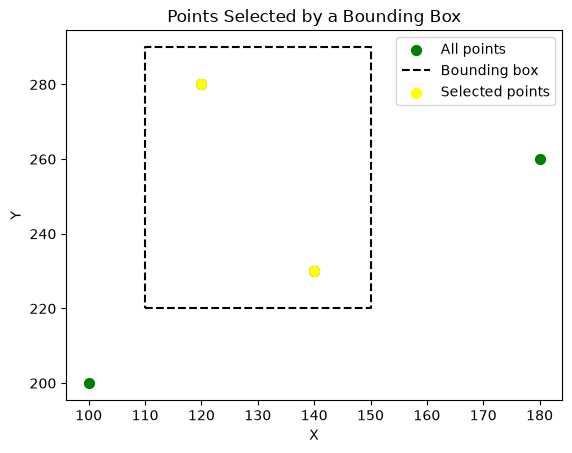

In [26]:
import matplotlib.pyplot as plt

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=50,
    label="All points",
    c='green'
)

plt.plot(
    [xmin, xmax, xmax, xmin, xmin],
    [ymin, ymin, ymax, ymax, ymin],
    label="Bounding box",
    linestyle="--",
    c='black'
)

plt.scatter(
    selected[:, 0],
    selected[:, 1],
    s=50,
    label="Selected points",
    c='yellow'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Points Selected by a Bounding Box")
plt.legend()
plt.show()

### Discussion

Before looking at the Boolean mask, could you identify the selected points from the graph?

How is this similar to selecting features inside a rectangle in ArcGIS/QGIS?

## Why vectorization matters
Python commands need to be interpreted before the computer executes them.  When you write a loop,
each command inside the loop is interpreted, then executed. Interpretation is generally slow.

Numpy vectorization takes advantage of custom-built numpy commands where the *loop itself has already been interpreted.*

>To see why this is better, think of a chef instructing the sous-chef to chop a bag of potatoes.  If the sous-chef only speaks French, then this workflow
> - Chef: "Chop this potato."
> - Interpreter : "Coupez la pomme de terre en morceaux."
> - Sous-chef: "Oui, Chef."
> - Chef: "Chop this potato."
> - Interpreter : "Coupez la pomme de terre  en morceaux."
> - Sous-chef: "Oui, Chef."
> - ...
>
> is less efficent than this one:
> - Chef: "Chop all the potatoes in this bag."
> - Numpy-Interpreter : "Coupez toutes les pommes de terre dans ce sac."
> - Sous-chef: "Oui, Chef."
>
>Or just run the code below.

In [27]:
import time

n = 500_000 ## means 500,000, but it is a number

python_values = list(range(n))
numpy_values = np.arange(n)

start = time.perf_counter() # get's the current time
print(start)
python_result = []
for value in python_values:
    python_result.append(value * 2)

python_time = time.perf_counter() - start #

start = time.perf_counter()

numpy_result = numpy_values * 2

numpy_time = time.perf_counter() - start

print("Time in seconds")
print("Python loop:", python_time)
print("NumPy:", numpy_time)

3161652.905375125
Time in seconds
Python loop: 0.02022295817732811
NumPy: 0.0007495000027120113


Your exact times will vary from computer to computer, but **the loop can be  20x slower**.

NumPy is optimized for operations on large numerical arrays. This is one reason it is so important in scientific computing, image processing, remote sensing, raster analysis, and GIS.

> You do not need to memorize these timing functions for an assessment -- this example is just to demonstrate the efficiency of numpy

##  NumPy x pandas

pandas and NumPy are closely related.

A pandas Series can be converted to a NumPy array:

In [28]:
import pandas as pd

df = pd.DataFrame({
    "x": [100, 140, 180, 120],
    "y": [200, 230, 260, 280]
})

x_array = df["x"].to_numpy()

x_array

array([100, 140, 180, 120])

A pandas DataFrame is convenient because it has column names/labels, mixed data types, and special methods for cleaning and tabular analysis.

NumPy is especially efficient for numerical arrays and vectorized math operations.  You will often see the two libraries used together.

## Practice — predict before running

Use the original `points` array:

```python
points = np.array([
    [100, 200],
    [140, 230],
    [180, 260],
    [120, 280]
])
```

Predict the result of each expression.

```python
points.shape
```

```python
points[1]
```

```python
points[:, 0]
```

```python
points[:, 1] > 250
```

```python
points[points[:, 0] > 130]
```

```python
points + np.array([5, 10])
```

### PREDICTION
(4, 2)\
[140, 230]\
[100, 140, 180, 120]\
[False, False, True, True]\
[140, 180]\
[105, 210], [145, 240], [185, 270], [125, 290]

In [29]:
print("shape:", points.shape)
print("second row:", points[1])
print("x coordinates:", points[:, 0])
print("y > 250:", points[:, 1] > 250)
print("x > 130:", points[points[:, 0] > 130])
print("shifted:", points + np.array([5, 10]))

shape: (4, 2)
second row: [140 230]
x coordinates: [100 140 180 120]
y > 250: [False False  True  True]
x > 130: [[140 230]
 [180 260]]
shifted: [[105 210]
 [145 240]
 [185 270]
 [125 290]]


## Final challenge

Use the array below:

In [30]:
sites = np.array([
    [681000, 3975000],
    [681400, 3975400],
    [681900, 3975900],
    [682300, 3976200],
    [680700, 3975700]
])

sites

array([[ 681000, 3975000],
       [ 681400, 3975400],
       [ 681900, 3975900],
       [ 682300, 3976200],
       [ 680700, 3975700]])

Complete these tasks first on paper and then create a JN:

- determine the shape of the array
- select all x-coordinates
- select all y-coordinates
- select points with x greater than `681500`
- create a Boolean mask for points with y greater than `3975600`
- use `np.where()` to label those points `"North"` and all others `"South"`
- use the first point as the origin and calculate the distance from it to every point
- create your own bounding box and select the points that fall inside it
- plot all points, the bounding box, and the selected points


### Paper
print("shape:", sites.shape)\
print("x-coordinates:", sites[:,0])\
print("y-coordinates:", sites[:,1])\
print("x > 681500:", sites(sites[;,0] > 681500))\
mask = sites[:, 1] > 3975600\
selected = sites[mask]\
print("mask:", selected)\
north_south = np.where(\
    sites[:, 0] > 681500 & sites[:, 1] > 3975600,\
    "North",\
    "South\
)\
print("North and South points:", north_south)\
origin = sites[0]\
difference = sites - origin\
print("distance:", difference)\
xmin, xmax = 681000, 682000\
ymin, ymax = 3975000, 3976000\
inside = (\
    (points[:, 0] >= xmin) &\
    (points[:, 0] <= xmax) &\
    (points[:, 1] >= ymin) &\
    (points[:, 1] <= ymax)\
)\
bounded = points[inside]\
print("Inside bounding box:", bounded)\
plt.scatter(\
    points[:, 0],\
    points[:, 1],\
    s=50,\
    label="All points",\
    c='green'\
)\
plt.plot(\
    [xmin, xmax, xmax, xmin, xmin],\
    [ymin, ymin, ymax, ymax, ymin],\
    label="Bounding box",\
    linestyle="--",\
    c='black'\
)\
plt.scatter(\
    selected[:, 0],\
    selected[:, 1],\
    s=50,\
    label="Selected points",\
    c='yellow'\
)\
plt.xlabel("X")\
plt.ylabel("Y")\
plt.title("Points Selected by a Bounding Box")\
plt.legend()\
plt.show()

shape: (5, 2)
x-coordinates: [681000 681400 681900 682300 680700]
y-coordinates: [3975000 3975400 3975900 3976200 3975700]
x > 681500: [[ 681900 3975900]
 [ 682300 3976200]]
mask: [[ 681900 3975900]
 [ 682300 3976200]
 [ 680700 3975700]]
North and South points: ['South' 'South' 'North' 'North' 'North']
distance: [[   0    0]
 [ 400  400]
 [ 900  900]
 [1300 1200]
 [-300  700]]
Inside bounding box: [[ 681400 3975400]
 [ 681900 3975900]
 [ 682300 3976200]]


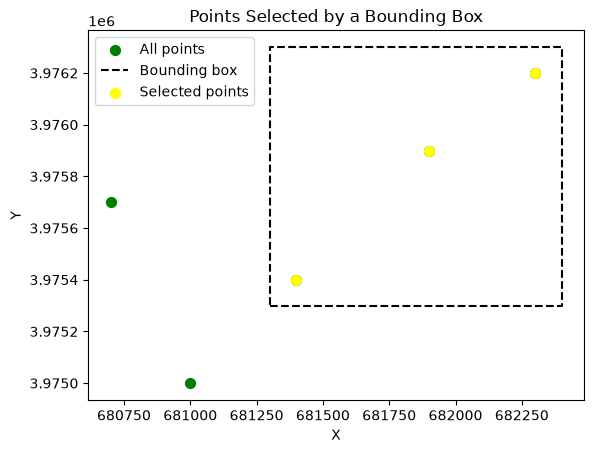

In [39]:
# Part 1
print("shape:", sites.shape)

# Part 2
print("x-coordinates:", sites[:,0])

# Part 3
print("y-coordinates:", sites[:,1])

# Part 4
print("x > 681500:", sites[sites[:,0] > 681500])

# Part 5
mask = sites[:, 1] > 3975600
selected = sites[mask]
print("mask:", selected)

# Part 6
north_south = np.where(
    sites[:,1] > 3975600,
    "North",
    "South"
)
print("North and South points:", north_south)

# Part 7
origin = sites[0]
difference = sites - origin
print("distance:", difference)

# Part 8
xmin, xmax = 681300, 682400
ymin, ymax = 3975300, 3976300

inside = (
    (sites[:, 0] >= xmin) &
    (sites[:, 0] <= xmax) &
    (sites[:, 1] >= ymin) &
    (sites[:, 1] <= ymax)
)

bounded = sites[inside]

print("Inside bounding box:", bounded)

# Part 9
plt.scatter(
    sites[:, 0],
    sites[:, 1],
    s=50,
    label="All points",
    c='green'
)

plt.plot(
    [xmin, xmax, xmax, xmin, xmin],
    [ymin, ymin, ymax, ymax, ymin],
    label="Bounding box",
    linestyle="--",
    c='black'
)

plt.scatter(
    bounded[:, 0],
    bounded[:, 1],
    s=50,
    label="Selected points",
    c='yellow'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Points Selected by a Bounding Box")
plt.legend()
plt.show()